# One day of the super-resolved sea level product

Set `DAY` below and run all cells. Reads `product/YYYY/sr_nordic_sla_YYYYMMDD.nc`
(1993-01-01 .. 2026).

Figures:
1. **Sea level anomaly**: DUACS input, deterministic `mu`, mean of the 8 members,
   4 members, ensemble spread, and SWOT if the day is in the SWOT record
   (2023-07-26 .. 2025-11).
2. **Geostrophic current speed**: DUACS, `mu` and the 4 members.
   Currents are computed from single members only: the ensemble mean is not a
   realisation, so its gradients are wrong by construction.
3. **Geostrophic kinetic energy**, same fields.
4. **Quality flag**: the four bits, one panel each.
5. **RMSE against SWOT** for SLA, currents and KE, raw and after smoothing both to
   20 km, with the best field for each.

In [1]:
DAY = "2025-10-21"          # YYYY-MM-DD, any day 1993-01-01 .. 2026
#DAY = "1994-01-15"          # YYYY-MM-DD, any day 1993-01-01 .. 2026
MEMBERS = [1, 2, 3, 4]       # which of the 8 realisations to show

from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # repo root

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

f = ROOT / "product" / DAY[:4] / f"sr_nordic_sla_{DAY.replace('-', '')}.nc"
ds = xr.open_dataset(f)                 # decodes scale_factor and _FillValue -> metres, NaN on land
print(f.name)
print("flags:", dict(zip(ds.quality_flag.flag_masks.tolist(), ds.quality_flag.flag_meanings.split())))

# SWOT for the same day, if it exists (gridded L3 ssha_filtered on the same fine grid)
swot = None
sw = xr.open_dataset(ROOT / "sr_duacs_to_swot.nc")
if np.datetime64(DAY) in sw.time.values.astype("datetime64[D]"):
    swot = sw.ssha.sel(time=DAY).values.squeeze()
    print(f"SWOT available: {100 * np.isfinite(swot).mean():.1f}% of the grid observed")
else:
    print("no SWOT on this day")

sr_nordic_sla_20251021.nc
flags: {1: 'near_coast', 2: 'input_out_of_distribution', 4: 'no_swot_validation', 8: 'in_training_period'}
SWOT available: 22.0% of the grid observed


In [3]:
lat, lon = ds.latitude.values, ds.longitude.values
dlat, dlon = ds.duacs_latitude.values, ds.duacs_longitude.values
ASPECT = 1 / np.cos(np.deg2rad(70.0))          # 1 deg lon ~ 38 km, 1 deg lat ~ 111 km at 70N
CM = 100.0                                     # plot in cm

duacs = ds.sla_duacs.values[0] * CM
mu = ds.sla_mu.values[0] * CM
mean = ds.sla_mean.values[0] * CM
ens = ds.sla.values[0] * CM                    # (8, lat, lon)
spread = np.nanstd(ens, axis=0, ddof=1)

vmin, vmax = np.nanpercentile(mu, [1, 99])     # one colour scale for every SLA panel
vmin, vmax = vmin - 2, vmax + 2

def panel(ax, x, y, z, title, **kw):
    im = ax.pcolormesh(x, y, z, shading="auto", **kw)
    ax.set_aspect(ASPECT); ax.set_title(title, fontsize=10)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    return im

/users/bernigau/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 1. Sea level anomaly

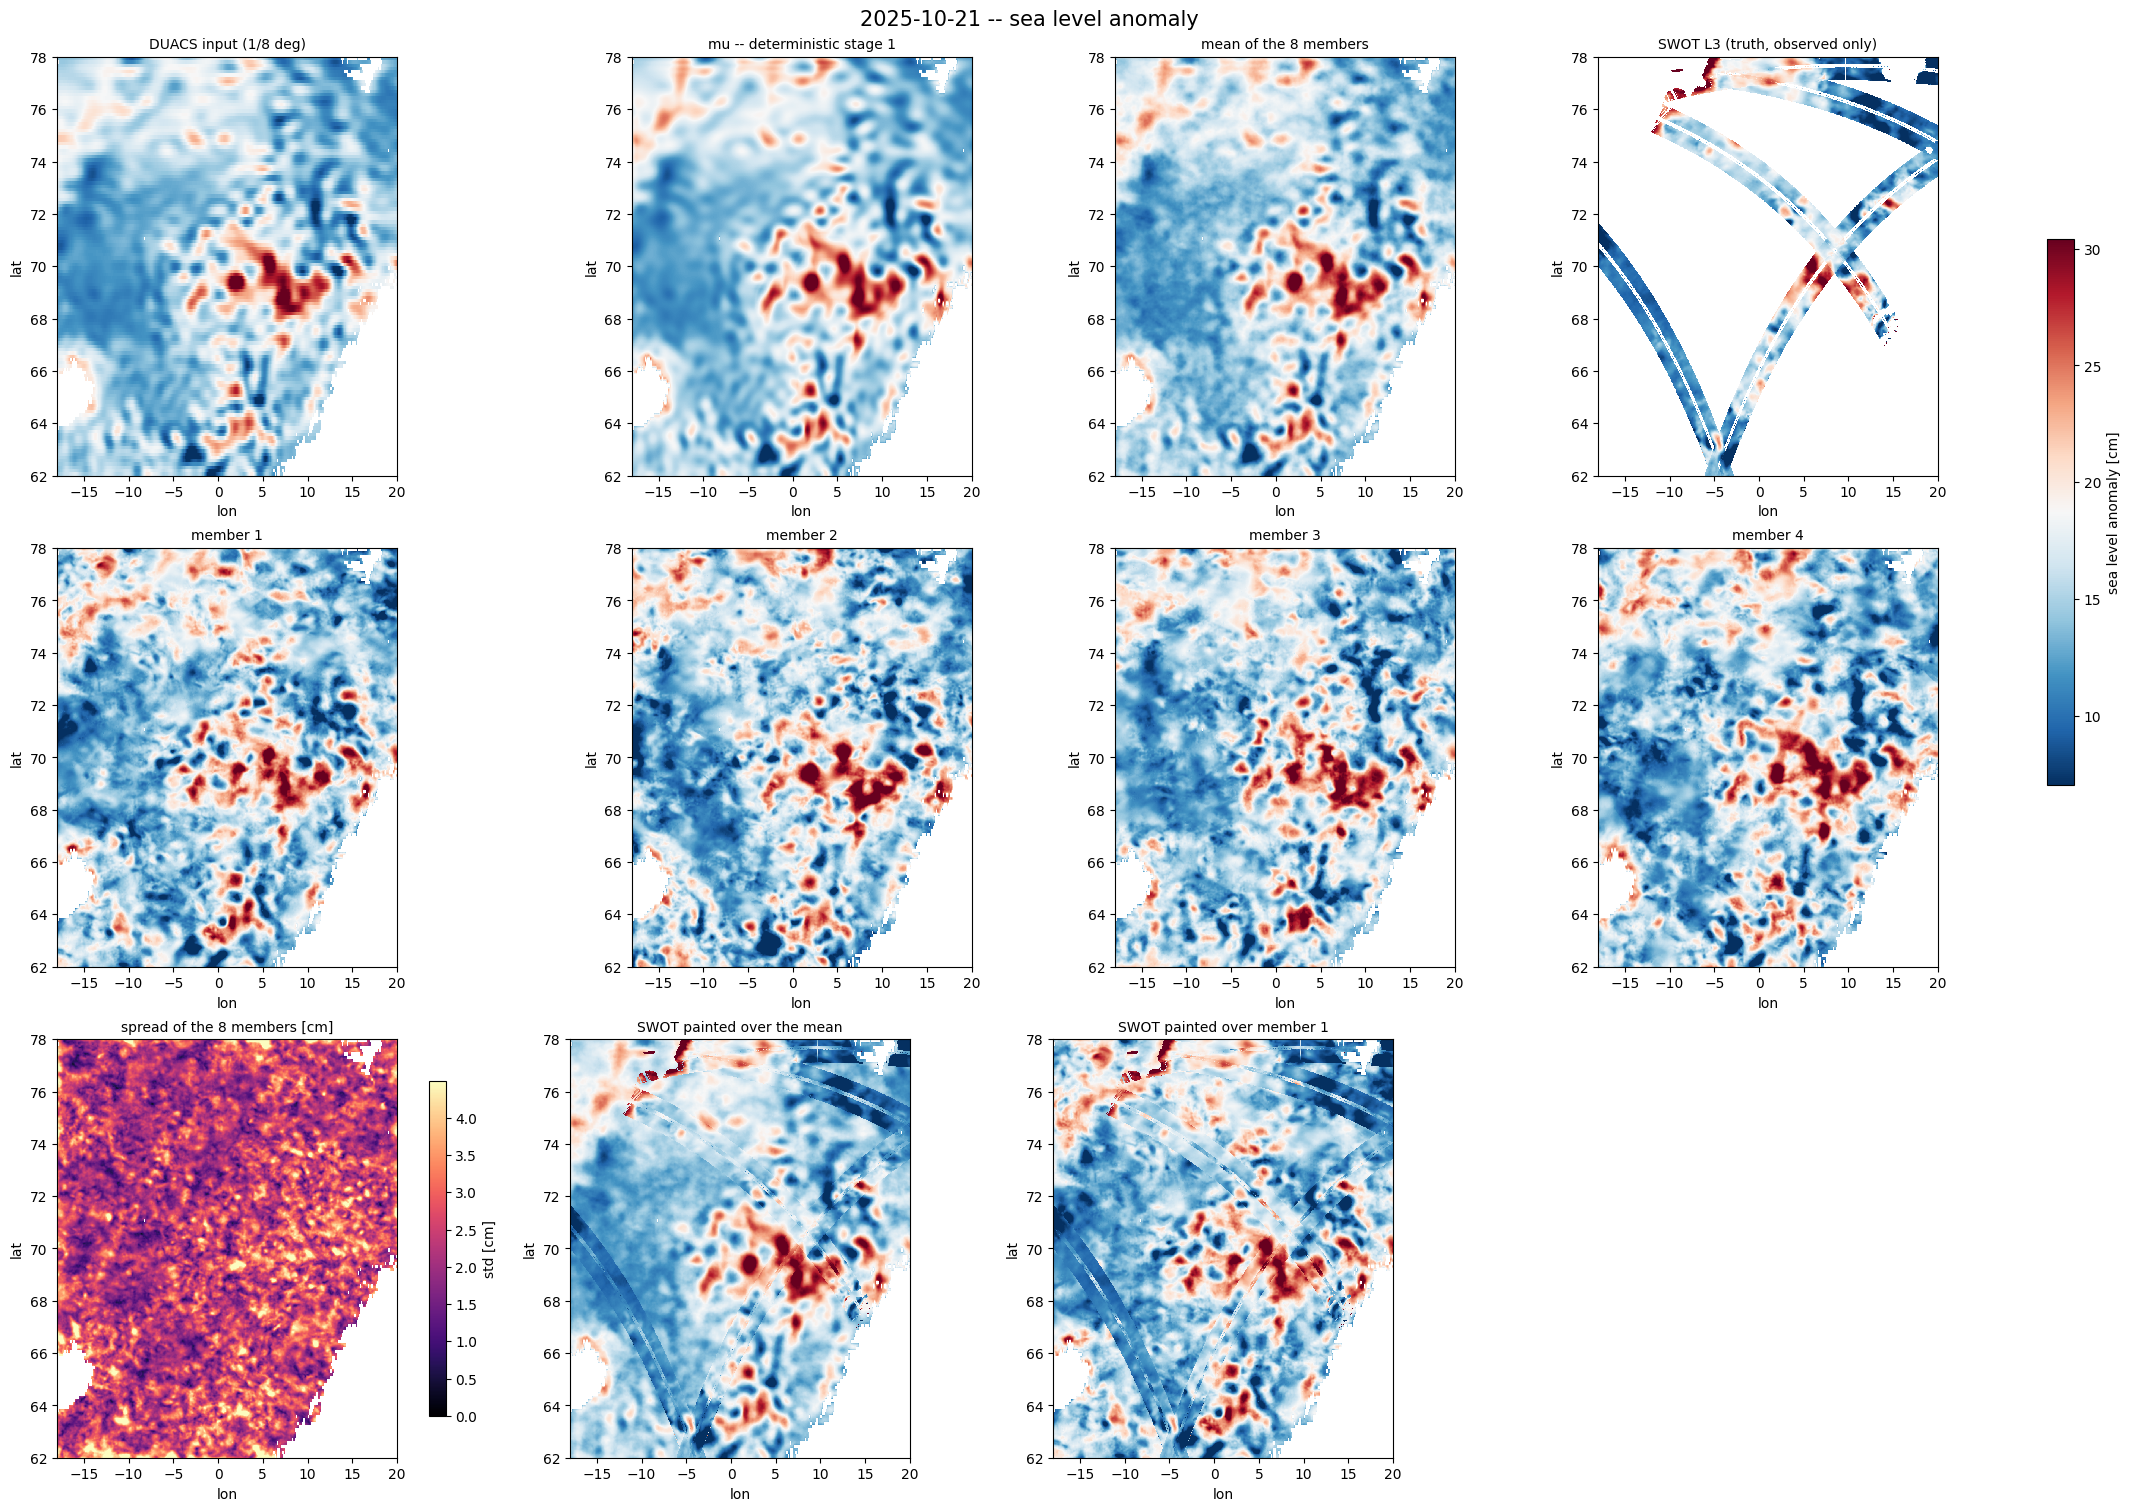

In [4]:
ssh = dict(cmap="RdBu_r", vmin=vmin, vmax=vmax)
fig, axs = plt.subplots(3, 4, figsize=(22, 15), constrained_layout=True)
panel(axs[0, 0], dlon, dlat, duacs, "DUACS input (1/8 deg)", **ssh)
panel(axs[0, 1], lon, lat, mu, "mu -- deterministic stage 1", **ssh)
im = panel(axs[0, 2], lon, lat, mean, "mean of the 8 members", **ssh)
if swot is not None:
    panel(axs[0, 3], lon, lat, swot * CM, "SWOT L3 (truth, observed only)", **ssh)
else:
    axs[0, 3].set_axis_off(); axs[0, 3].text(0.5, 0.5, "no SWOT this day", ha="center")
for k, m in enumerate(MEMBERS):
    panel(axs[1, k], lon, lat, ens[m - 1], f"member {m}", **ssh)
im_sp = panel(axs[2, 0], lon, lat, spread, "spread of the 8 members [cm]",
              cmap="magma", vmin=0, vmax=np.nanpercentile(spread, 99))
if swot is not None:
    panel(axs[2, 1], lon, lat, mean, "SWOT painted over the mean", **ssh)
    axs[2, 1].pcolormesh(lon, lat, np.ma.masked_invalid(swot * CM), shading="auto", **ssh)
    panel(axs[2, 2], lon, lat, ens[MEMBERS[0] - 1], f"SWOT painted over member {MEMBERS[0]}", **ssh)
    axs[2, 2].pcolormesh(lon, lat, np.ma.masked_invalid(swot * CM), shading="auto", **ssh)
else:
    axs[2, 1].set_axis_off(); axs[2, 2].set_axis_off()
axs[2, 3].set_axis_off()
fig.colorbar(im, ax=axs[:2], shrink=0.6, label="sea level anomaly [cm]")
fig.colorbar(im_sp, ax=axs[2, 0], shrink=0.8, label="std [cm]")
fig.suptitle(f"{DAY} -- sea level anomaly", fontsize=15)
plt.show()

## 2. Geostrophic current speed (single fields only)

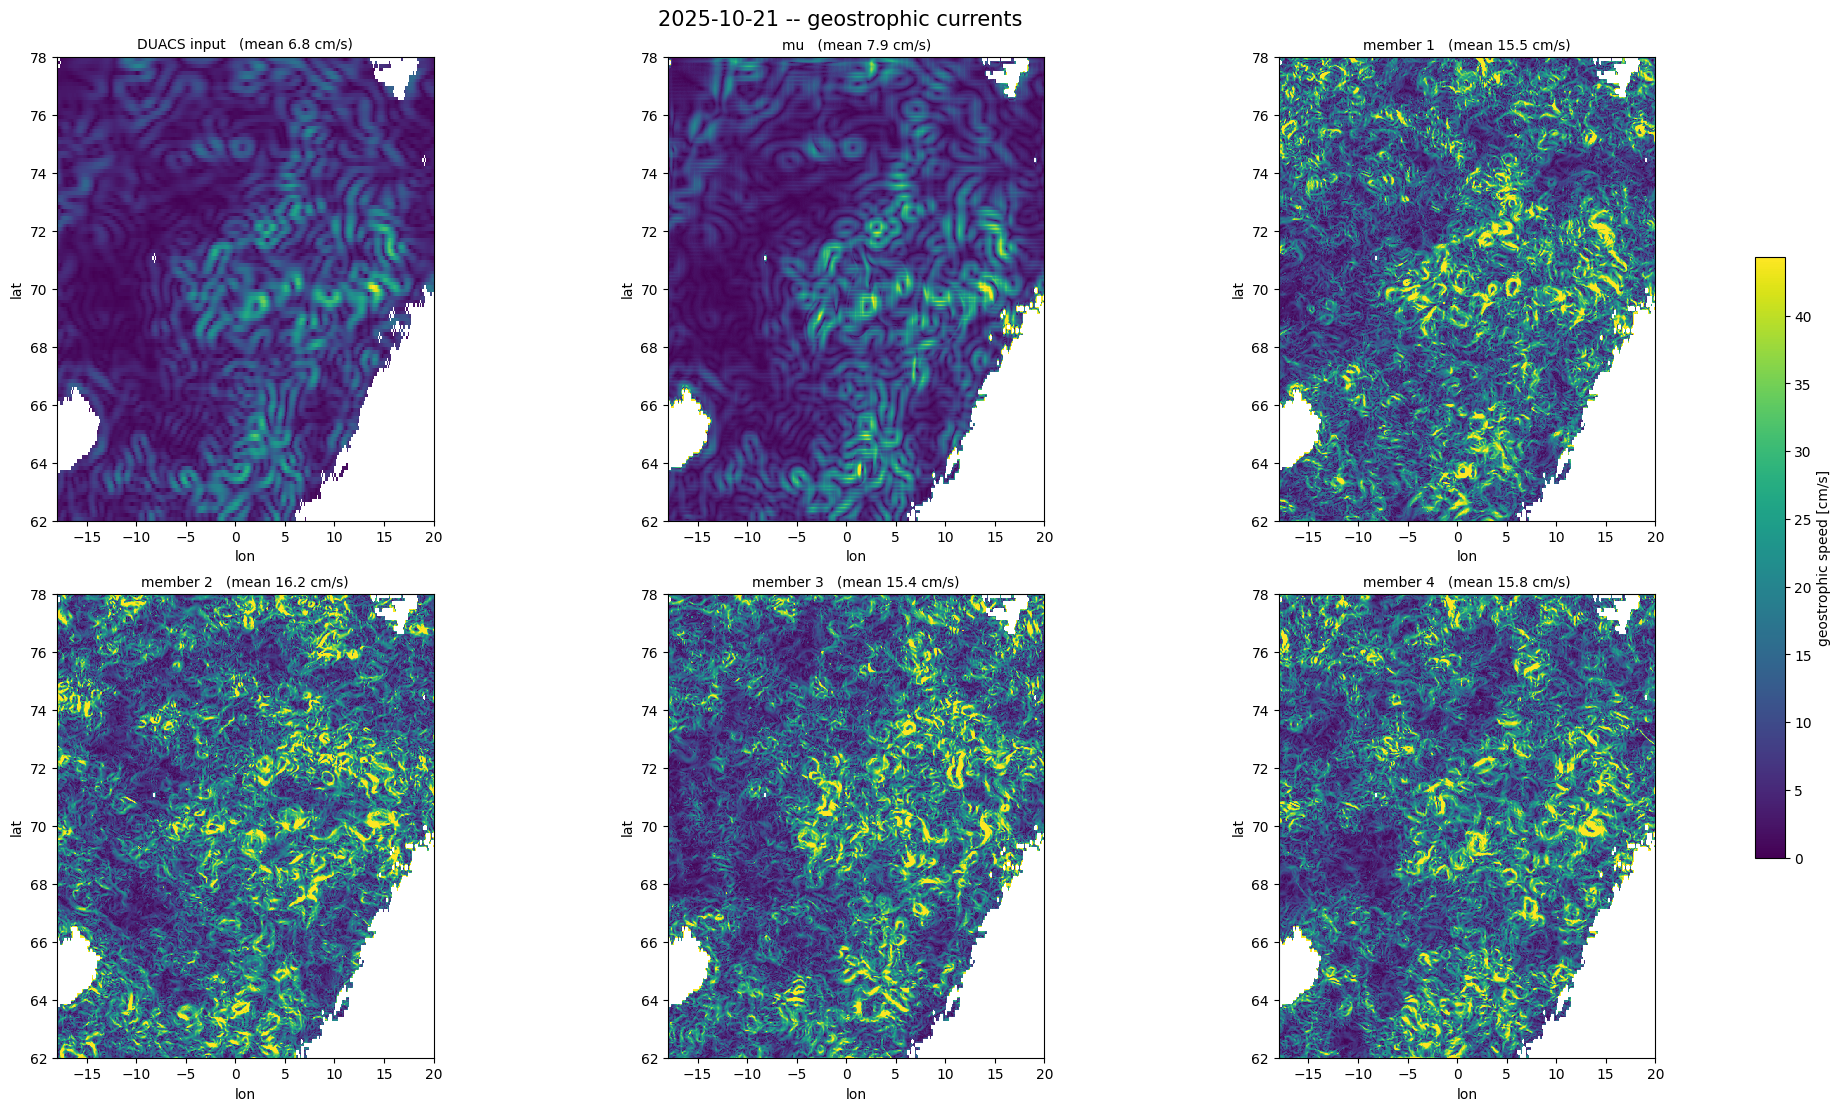

In [5]:
G, OMEGA = 9.81, 7.2921e-5

def geo_speed(eta_cm, la, lo):
    """|u_g| = g/|f| |grad eta| in cm/s, centred differences on a regular lat/lon grid."""
    eta = eta_cm / 100.0
    f = 2 * OMEGA * np.sin(np.deg2rad(la))[:, None]
    dy = np.gradient(la) * 111_320.0
    dx = np.gradient(lo)[None, :] * 111_320.0 * np.cos(np.deg2rad(la))[:, None]
    gy = np.gradient(eta, axis=0) / dy[:, None]
    gx = np.gradient(eta, axis=1) / dx
    return 100.0 * G / np.abs(f) * np.hypot(gx, gy)

sp = {"DUACS input": geo_speed(duacs, dlat, dlon), "mu": geo_speed(mu, lat, lon)}
for m in MEMBERS:
    sp[f"member {m}"] = geo_speed(ens[m - 1], lat, lon)
vtop = np.nanpercentile(sp[f"member {MEMBERS[0]}"], 98)

fig, axs = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
for ax, (name, s) in zip(axs.flat, sp.items()):
    x, y = (dlon, dlat) if name.startswith("DUACS") else (lon, lat)
    im = panel(ax, x, y, s, f"{name}   (mean {np.nanmean(s):.1f} cm/s)",
               cmap="viridis", vmin=0, vmax=vtop)
fig.colorbar(im, ax=axs, shrink=0.6, label="geostrophic speed [cm/s]")
fig.suptitle(f"{DAY} -- geostrophic currents", fontsize=15)
plt.show()

## 3. Geostrophic kinetic energy

KE = ½ (u² + v²) from the geostrophic velocities of each **single** field, in cm²/s².
It weights the small scales even more than the speed does, so this is where the
members and `mu` differ most.

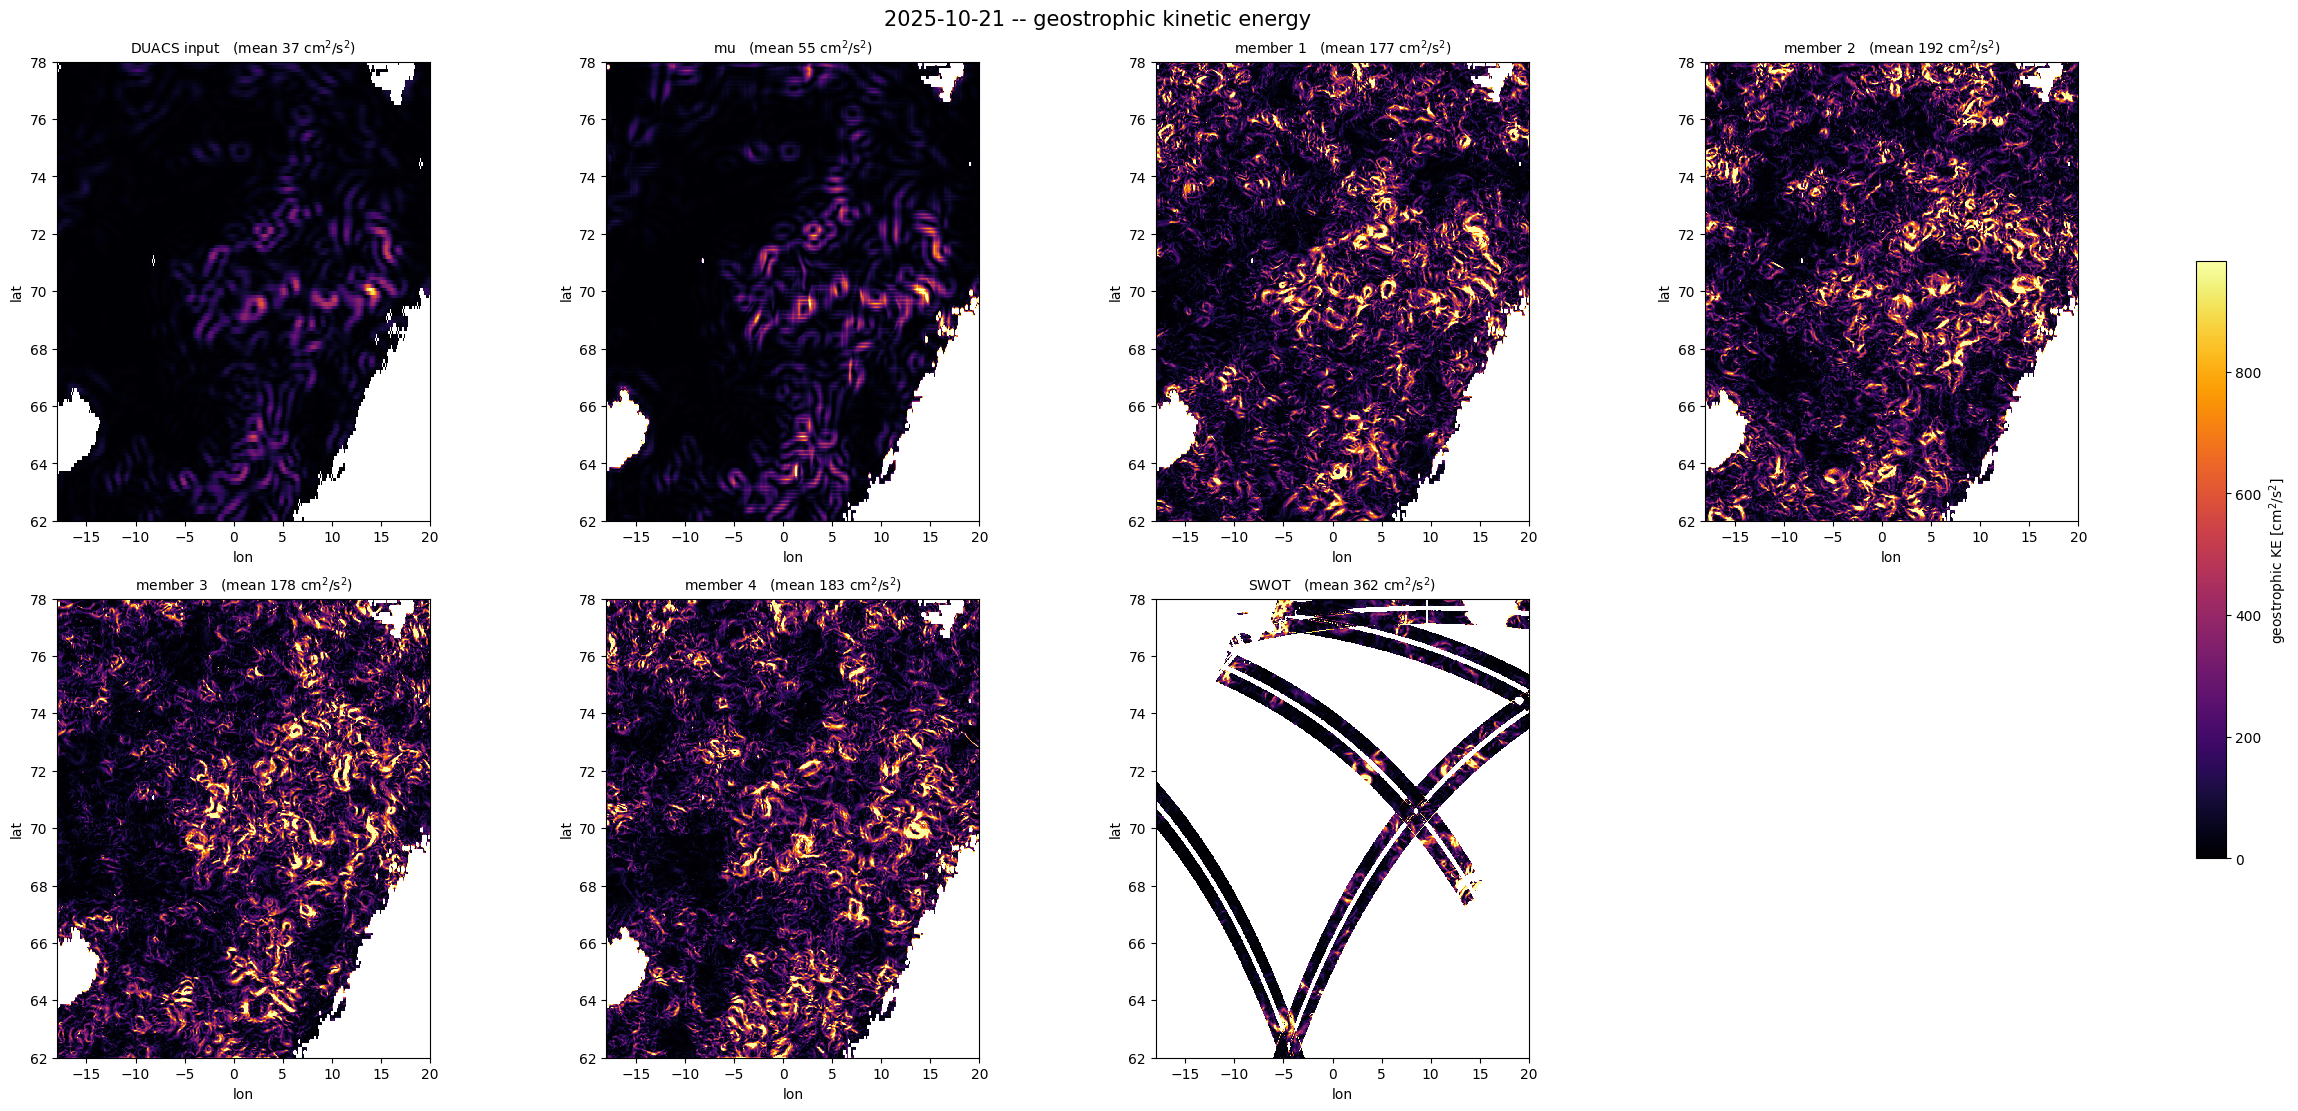

In [6]:
def geo_uv(eta_cm, la, lo):
    """Geostrophic (u, v) in cm/s: u = -g/f d(eta)/dy, v = g/f d(eta)/dx."""
    eta = eta_cm / 100.0
    f = 2 * OMEGA * np.sin(np.deg2rad(la))[:, None]
    dy = np.gradient(la)[:, None] * 111_320.0
    dx = np.gradient(lo)[None, :] * 111_320.0 * np.cos(np.deg2rad(la))[:, None]
    u = -G / f * np.gradient(eta, axis=0) / dy
    v = G / f * np.gradient(eta, axis=1) / dx
    return 100.0 * u, 100.0 * v

RY, RX = len(lat) // len(dlat), len(lon) // len(dlon)      # 8 x 3 block refinement
def to_fine(a):                                           # DUACS-grid field -> fine grid
    return np.repeat(np.repeat(a, RY, 0), RX, 1)

# every field on the fine grid; DUACS velocities are its own (coarse-grid) gradients
uv = {"DUACS input": tuple(to_fine(c) for c in geo_uv(duacs, dlat, dlon)),
      "mu": geo_uv(mu, lat, lon)}
for m in MEMBERS:
    uv[f"member {m}"] = geo_uv(ens[m - 1], lat, lon)
if swot is not None:
    uv["SWOT"] = geo_uv(swot * CM, lat, lon)             # NaN outside the swaths
ke = {k: 0.5 * (u ** 2 + v ** 2) for k, (u, v) in uv.items()}

ktop = np.nanpercentile(ke[f"member {MEMBERS[0]}"], 98)
fig, axs = plt.subplots(2, 4, figsize=(24, 11), constrained_layout=True)
for ax, (name, k) in zip(axs.flat, ke.items()):
    im = panel(ax, lon, lat, k, f"{name}   (mean {np.nanmean(k):.0f} cm$^2$/s$^2$)",
               cmap="inferno", vmin=0, vmax=ktop)
for ax in list(axs.flat)[len(ke):]:
    ax.set_axis_off()
fig.colorbar(im, ax=axs, shrink=0.6, label="geostrophic KE [cm$^2$/s$^2$]")
fig.suptitle(f"{DAY} -- geostrophic kinetic energy", fontsize=15)
plt.show()

## 4. Quality flag

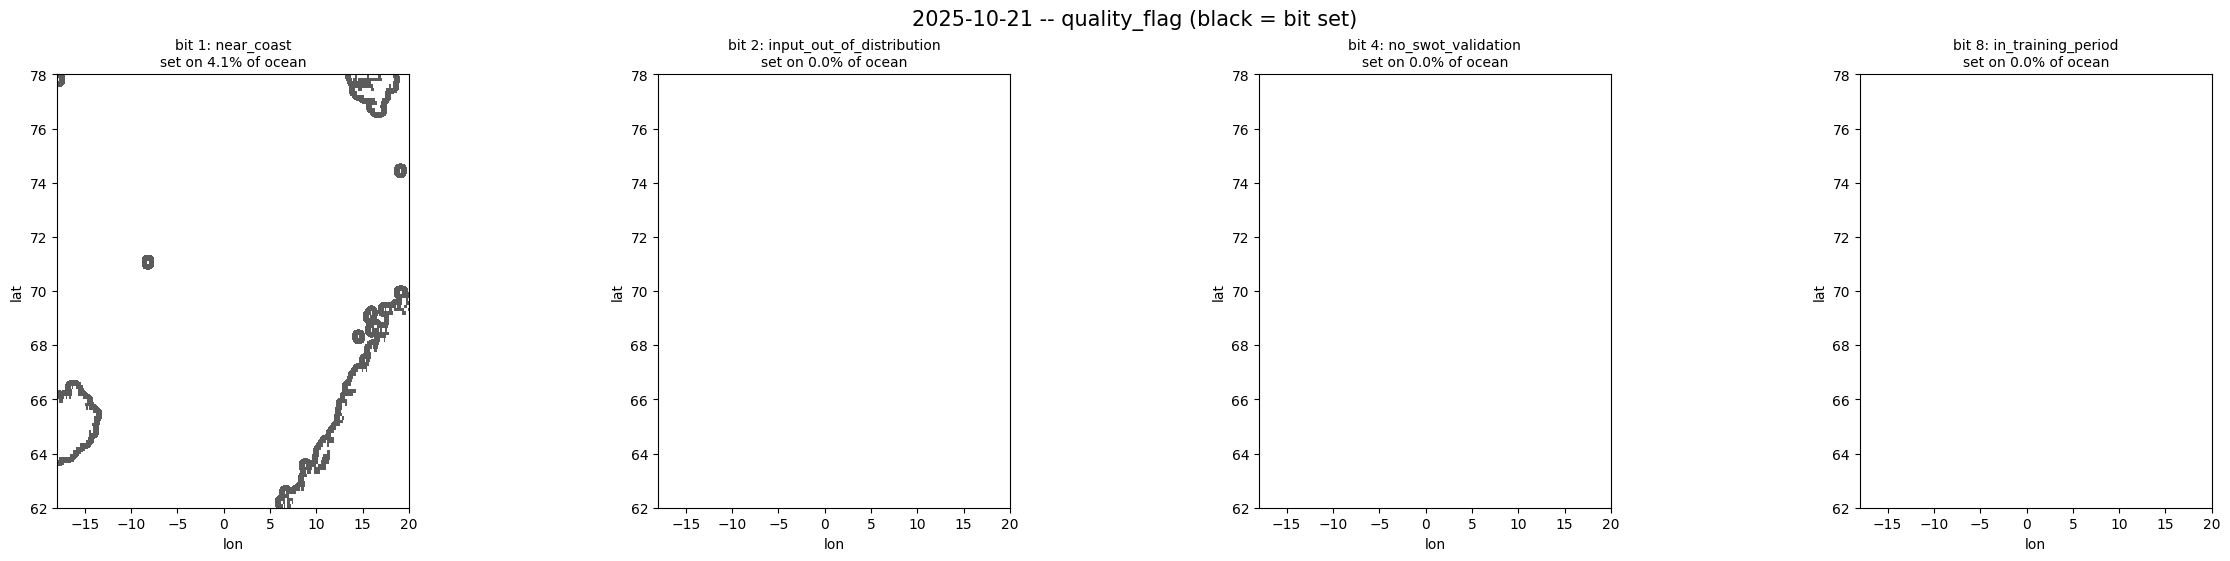

1 near_coast: within 25 km of DUACS land: ensemble CRPS skill over DUACS falls from 28% offshore to 16% at 10-25 km and 5% within 10 km
2 input_out_of_distribution: this day's DUACS gradient energy is below the 1st percentile of the training period: the model is extrapolating.  Set on 89-100% of days in 1993-1999 (input ~0.5x the training median) and 60-100% until 2015; 0-7% from 2017
4 no_swot_validation: date before the SWOT era (2023-07-26): no independent truth exists to validate this day
8 in_training_period: date inside the training period 2023-07-26..2025-02-28: the model was trained on SWOT for this day, so agreement with SWOT is not an independent evaluation


In [7]:
q = ds.quality_flag.values[0]
ocean = np.isfinite(mu)
bits = list(zip(ds.quality_flag.flag_masks.tolist(), ds.quality_flag.flag_meanings.split()))
fig, axs = plt.subplots(1, len(bits), figsize=(6 * len(bits), 5.5), constrained_layout=True)
for ax, (b, name) in zip(axs, bits):
    on = np.where(ocean, (q & b) > 0, np.nan).astype(float)
    panel(ax, lon, lat, on, f"bit {b}: {name}\nset on {100 * np.nanmean(on):.1f}% of ocean",
          cmap="Greys", vmin=0, vmax=1.4)
fig.suptitle(f"{DAY} -- quality_flag (black = bit set)", fontsize=15)
plt.show()
import re
print("\n".join(re.split(r"; (?=\d+ [a-z_]+:)", ds.quality_flag.comment)))

## 5. RMSE against SWOT

Every field is scored twice, on the pixels where SWOT and every field are all defined:

- **raw**: the fields as they are;
- **smoothed**: SWOT and every field are first smoothed identically with a Gaussian
  that has half amplitude at `SMOOTH_KM` (20 km by default, roughly SWOT's effective
  resolution), and currents and KE are then computed from the smoothed sea level.

The smoothing matters most for currents and KE.  They are gradients of sea level,
so they amplify the small scales.  Below ~15 km the gridded SWOT field has 3-30x too
much energy from the gridding, plus instrument noise.  In the raw scores that noise
dominates: every field gets nearly the same KE RMSE, so the "best" one is arbitrary.
SWOT is gappy, so the smoothing uses normalised convolution, and only pixels where
the smoothing had >= 90% support (well inside a swath) are scored.

Pixels where |SWOT| > 0.5 m (0.02% of the record, outliers) are EXCLUDED rather than
clipped: clipping flattens them into plateaus whose edges become spurious currents.
DUACS is bilinearly interpolated onto the fine grid for scoring -- block-repeating it
would give it staircase gradients and penalise its currents for an artifact of the
regridding.  Currents are scored as a vector (u and v together).

**Smooth fields win RMSE by construction.**  A member puts eddies at full amplitude,
so a slightly misplaced eddy is penalised twice (a miss and a false alarm); `mu` and
the mean never are.  RMSE says which map is closest point by point, not which is
most realistic.

In [8]:
SMOOTH_KM = 20.0            # half-amplitude wavelength of the Gaussian smoothing

from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator

def duacs_on_fine():
    """DUACS bilinearly interpolated onto the fine grid, NaN where it touches land."""
    ok = np.isfinite(duacs)
    it = RegularGridInterpolator((dlat, dlon), np.where(ok, duacs, 0.0),
                                 bounds_error=False, fill_value=None)
    iw = RegularGridInterpolator((dlat, dlon), ok.astype(float),
                                 bounds_error=False, fill_value=None)
    LA, LO = np.meshgrid(lat, lon, indexing="ij")
    pts = np.stack([LA.ravel(), LO.ravel()], -1)
    val, w = it(pts).reshape(LA.shape), iw(pts).reshape(LA.shape)
    return np.where(w > 0.999, val / np.maximum(w, 1e-9), np.nan)

def smooth(a, km=SMOOTH_KM):
    """Gap-aware Gaussian smoothing: smooth(a*valid)/smooth(valid), and the support."""
    sig_km = np.sqrt(np.log(2.0) * km ** 2 / (2 * np.pi ** 2))
    dy_km = np.abs(np.gradient(lat)).mean() * 111.32
    dx_km = np.abs(np.gradient(lon)).mean() * 111.32 * np.cos(np.deg2rad(lat.mean()))
    s = (sig_km / dy_km, sig_km / dx_km)
    ok = np.isfinite(a)
    w = gaussian_filter(ok.astype(float), s, mode="constant")
    out = gaussian_filter(np.where(ok, a, 0.0), s, mode="constant") / np.maximum(w, 1e-9)
    return np.where(ok, out, np.nan), w

def score(truth, preds, extra_ok=None):
    """RMSE of SLA, vector currents and KE for each field on one common mask."""
    su, sv = geo_uv(truth, lat, lon)
    ok = np.isfinite(truth) & np.isfinite(su) & np.isfinite(sv)
    if extra_ok is not None:
        ok &= extra_ok
    uvs = {k: geo_uv(v, lat, lon) for k, v in preds.items()}
    for k, v in preds.items():
        ok &= np.isfinite(v) & np.isfinite(uvs[k][0]) & np.isfinite(uvs[k][1])
    ke_t = 0.5 * (su ** 2 + sv ** 2)
    rows = {}
    for k, v in preds.items():
        u_, v_ = uvs[k]
        rows[k] = (np.sqrt(np.mean((v - truth)[ok] ** 2)),
                   np.sqrt(np.mean(((u_ - su) ** 2 + (v_ - sv) ** 2)[ok])),
                   np.sqrt(np.mean((0.5 * (u_ ** 2 + v_ ** 2) - ke_t)[ok] ** 2)))
    return rows, ok.sum()

def report(title, rows, n):
    print(f"\n=== {title}: {n:,} pixels ===")
    print(f"{'field':14s}{'SLA [cm]':>11}{'currents [cm/s]':>17}{'KE [cm2/s2]':>14}")
    for k, r in rows.items():
        print(f"{k:14s}{r[0]:>11.3f}{r[1]:>17.3f}{r[2]:>14.2f}")
    for i, what in enumerate(("SLA", "currents", "kinetic energy")):
        best = min(rows, key=lambda k: rows[k][i])
        print(f"  lowest RMSE for {what:15s}: {best}  ({rows[best][i]:.3f})")

if swot is None:
    print("No SWOT data available on this day")
else:
    if ds.quality_flag.values[0].max() & 8:
        print("NOTE: inside the training period -- the model saw SWOT for this day, "
              "so this is not an independent evaluation")
    truth = np.where(np.abs(swot) <= 0.5, swot, np.nan) * CM   # exclude outliers
    preds = {"DUACS input": duacs_on_fine(), "mu": mu, "mean of 8": mean}
    for m in MEMBERS:
        preds[f"member {m}"] = ens[m - 1]

    rows, n = score(truth, preds)
    report("raw", rows, n)

    truth_s, support = smooth(truth)
    preds_s = {k: smooth(v)[0] for k, v in preds.items()}
    rows_s, n_s = score(truth_s, preds_s, extra_ok=support >= 0.9)
    report(f"smoothed to {SMOOTH_KM:g} km", rows_s, n_s)


=== raw: 192,006 pixels ===
field            SLA [cm]  currents [cm/s]   KE [cm2/s2]
DUACS input         3.118           16.571       2142.88
mu                  3.167           16.656       2142.27
mean of 8           3.254           17.410       2141.78
member 1            3.937           23.049       2155.47
member 2            3.968           23.640       2154.91
member 3            3.900           23.125       2152.14
member 4            4.085           23.265       2152.02
  lowest RMSE for SLA            : DUACS input  (3.118)
  lowest RMSE for currents       : DUACS input  (16.571)
  lowest RMSE for kinetic energy : mean of 8  (2141.777)

=== smoothed to 20 km: 164,178 pixels ===
field            SLA [cm]  currents [cm/s]   KE [cm2/s2]
DUACS input         2.900           10.986        179.94
mu                  2.960           11.059        176.24
mean of 8           3.045           11.713        174.25
member 1            3.734           16.609        248.91
member 2         